# Nama: Hizam Machendra Mifta
# NIM: 4222301045
# Kelas: Robotika B pagi Sem 6

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
from pathlib import Path

csv_candidates = [
    Path('WineQT.csv'),
    Path('/mnt/data/WineQT(2).csv'),
]

for csv_file in csv_candidates:
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        break
else:
    raise FileNotFoundError('WineQT(2).csv tidak ditemukan di folder kerja atau /mnt/data')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA

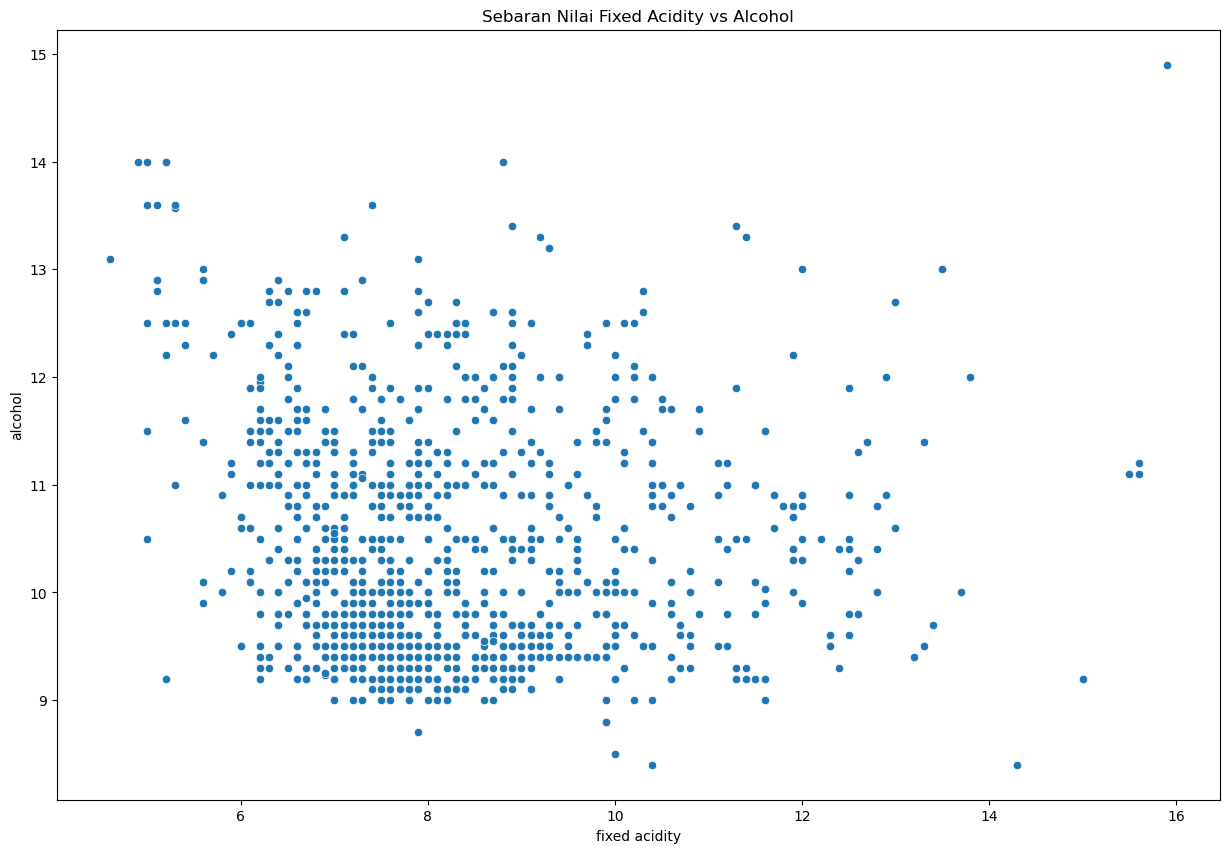

In [3]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol')
plt.title('Sebaran Nilai Fixed Acidity vs Alcohol')
plt.show()

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


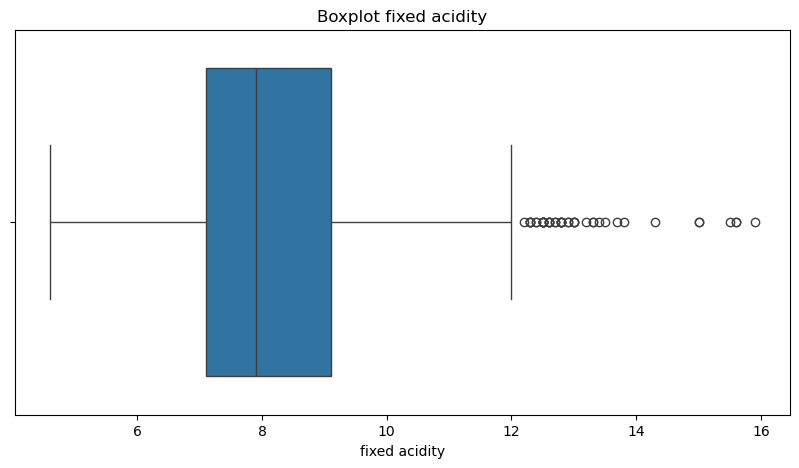

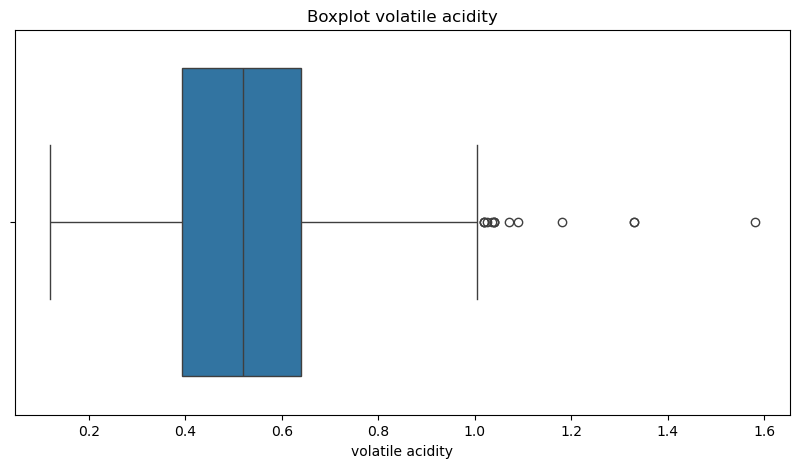

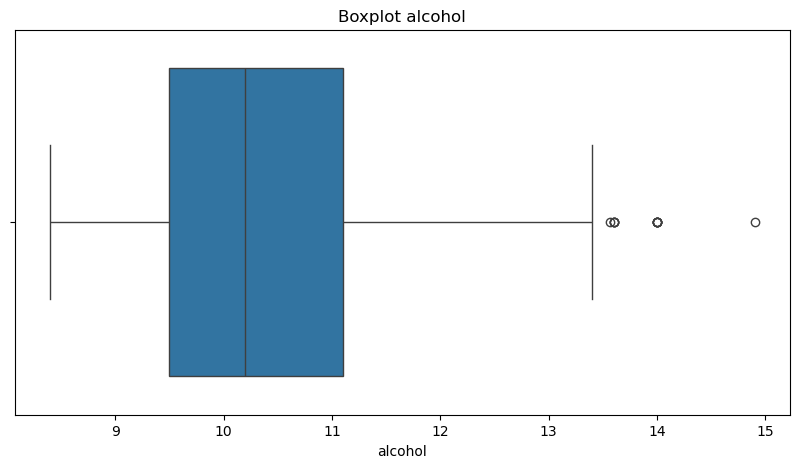

In [5]:
# Looping untuk beberapa kolom numerik
columns = ['fixed acidity', 'volatile acidity', 'alcohol']

for col in columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

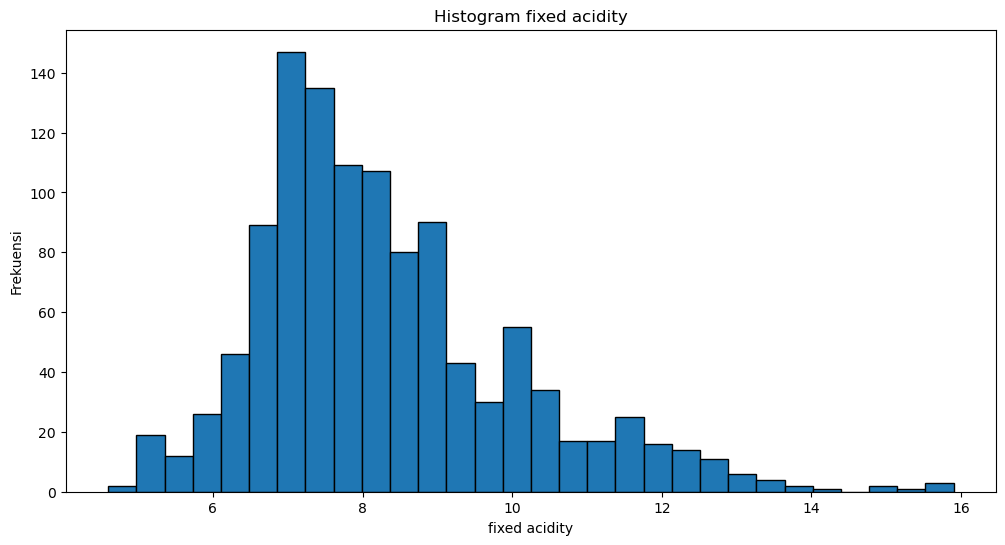

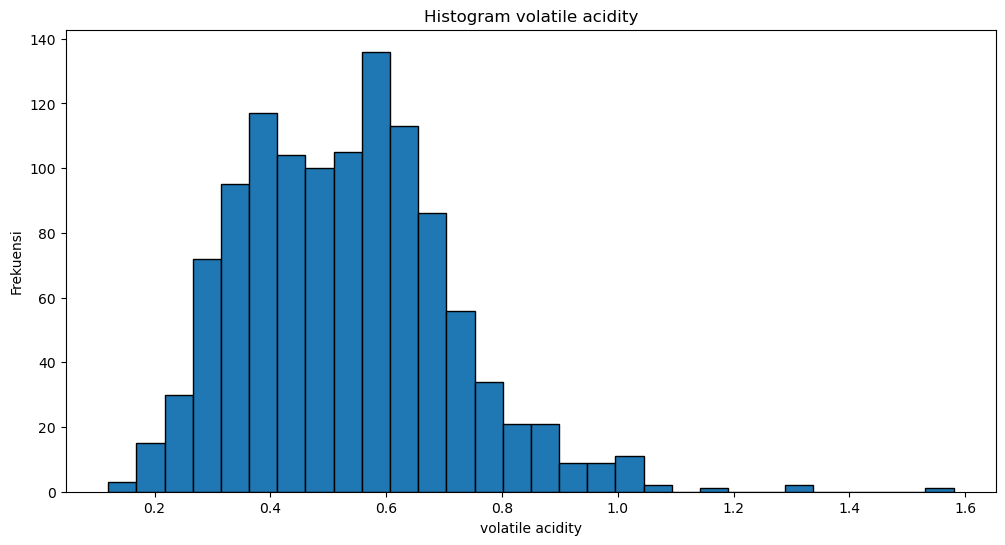

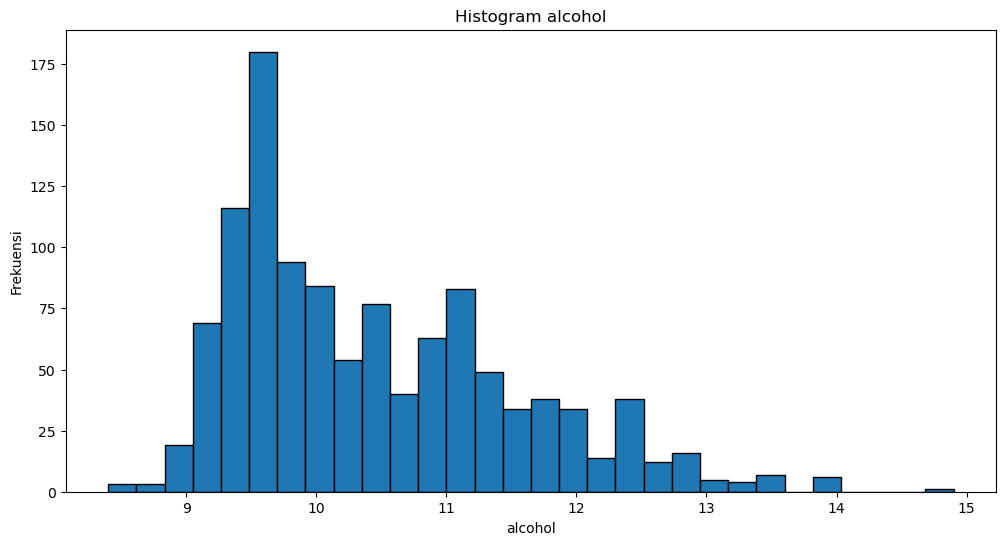

In [6]:
for col in columns:
    plt.figure(figsize=(12, 6))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [7]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

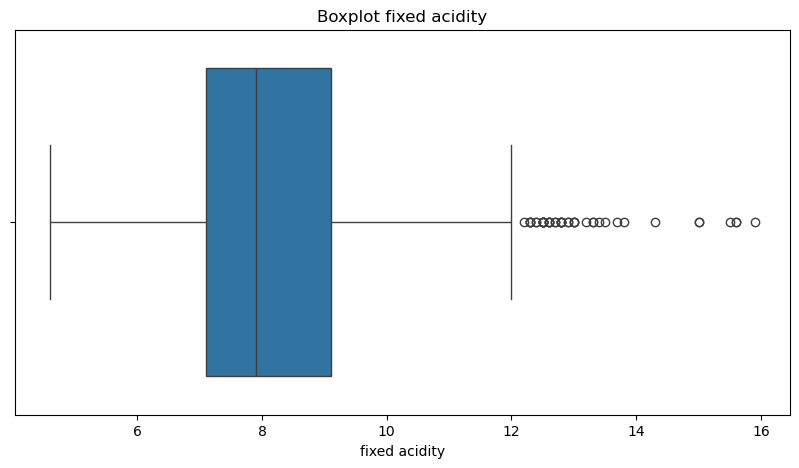

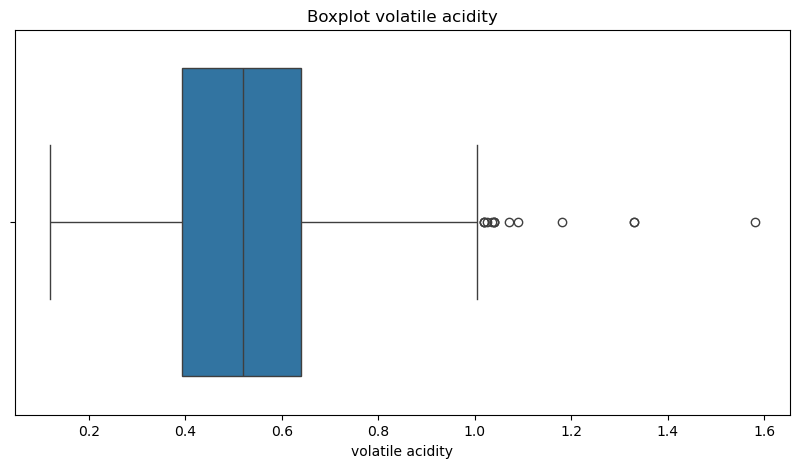

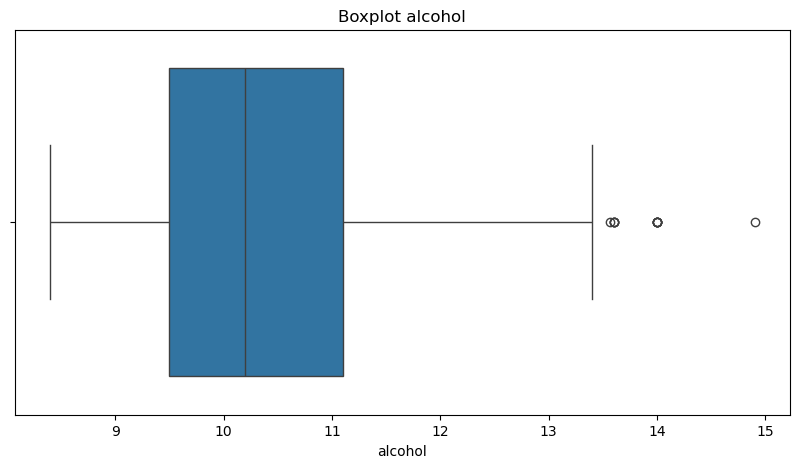

In [8]:
# Looping untuk beberapa kolom numerik
columns = ['fixed acidity', 'volatile acidity', 'alcohol']

for col in columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

In [9]:
# Pemilihan fitur untuk clustering
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'alcohol']

# Mengambil data fitur
X = df[fitur_columns].values

# Label quality (opsional untuk pembanding)
y = df['quality'].values


In [10]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,4.121103e+00


In [11]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 ,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 ,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, -0.22382033]],
      shape=(1143, 4))

In [12]:
df_scalling

,fixed acidity,volatile acidity,citric acid,alcohol
0,-0.521580,0.939332,-1.365027,-0.963382
1,-0.292593,1.941813,-1.365027,-0.593601
2,-0.292593,1.273492,-1.161568,-0.593601
3,1.653789,-1.399789,1.483400,-0.593601
4,-0.521580,0.939332,-1.365027,-0.963382
...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,0.515741
1139,-0.865059,0.493785,-0.958109,-0.870937
1140,-1.208538,0.382399,-0.958109,0.053515
1141,-1.380278,0.103932,-0.856379,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

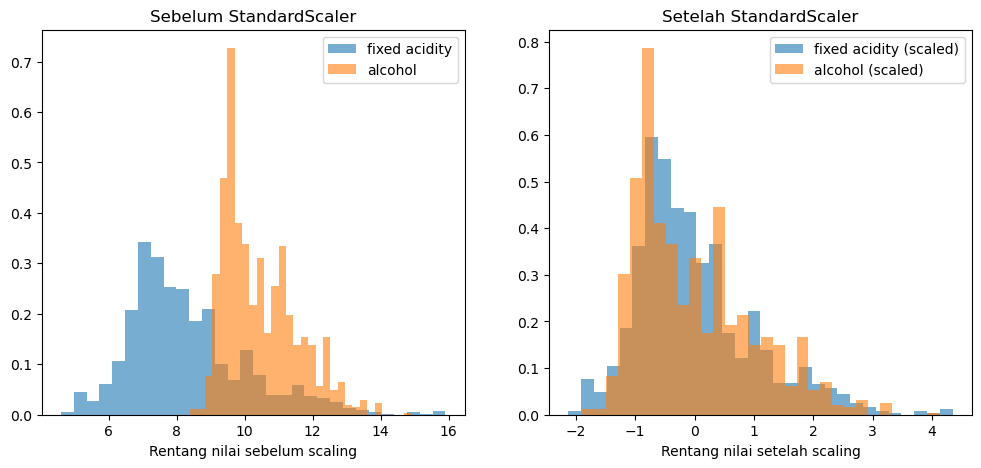

In [13]:
# Cek grafik sebelum dan setelah scaling
# Kita lihat distribusi dari variabel sebelum StandardScaler dan setelah StandardScaler

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum StandardScaler
ax1.set_title('Sebelum StandardScaler')
ax1.hist(df['fixed acidity'], bins=30, alpha=0.6, label='fixed acidity', density=True)
ax1.hist(df['alcohol'], bins=30, alpha=0.6, label='alcohol', density=True)

# Plot distribusi setelah StandardScaler
ax2.set_title('Setelah StandardScaler')
ax2.hist(df_scalling['fixed acidity'], bins=30, alpha=0.6, label='fixed acidity (scaled)', density=True)
ax2.hist(df_scalling['alcohol'], bins=30, alpha=0.6, label='alcohol (scaled)', density=True)

ax1.set_xlabel('Rentang nilai sebelum scaling')
ax2.set_xlabel('Rentang nilai setelah scaling')

ax1.legend()
ax2.legend()

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. terlihat pada plot diatas merupakan visualisasi sebelum dan sesudah menggunakan feature scalling  . terlihat pada visualisasi data rentan nilai terlihat lebih kecil dan lebih stabil ketimbang sebelum menggunakan feature scalling  


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

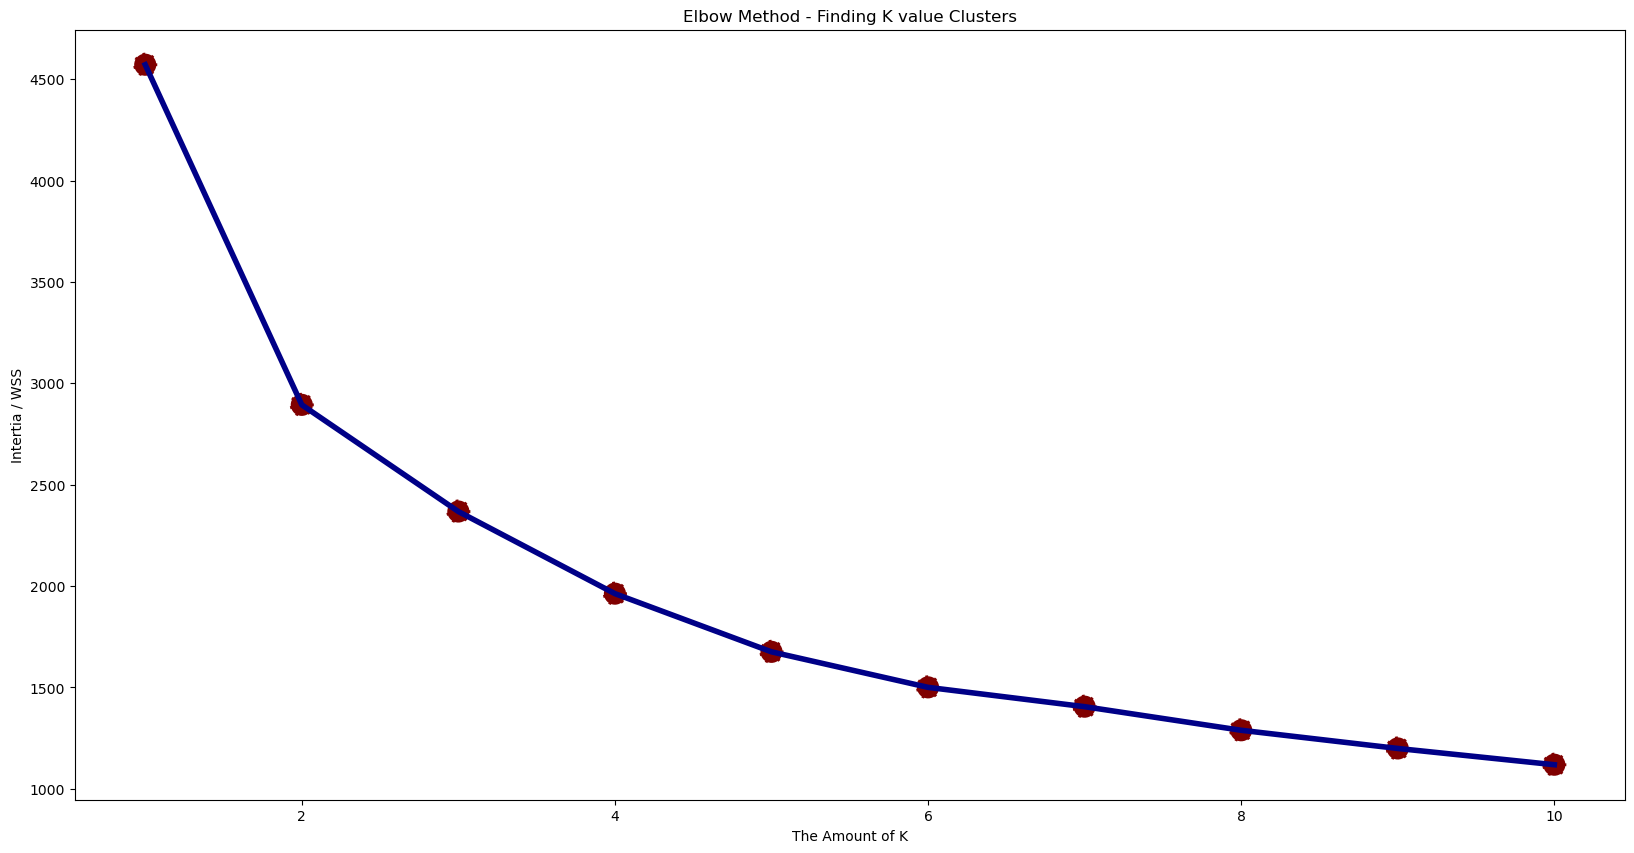

In [14]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [15]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [16]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [17]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,3
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,2
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3


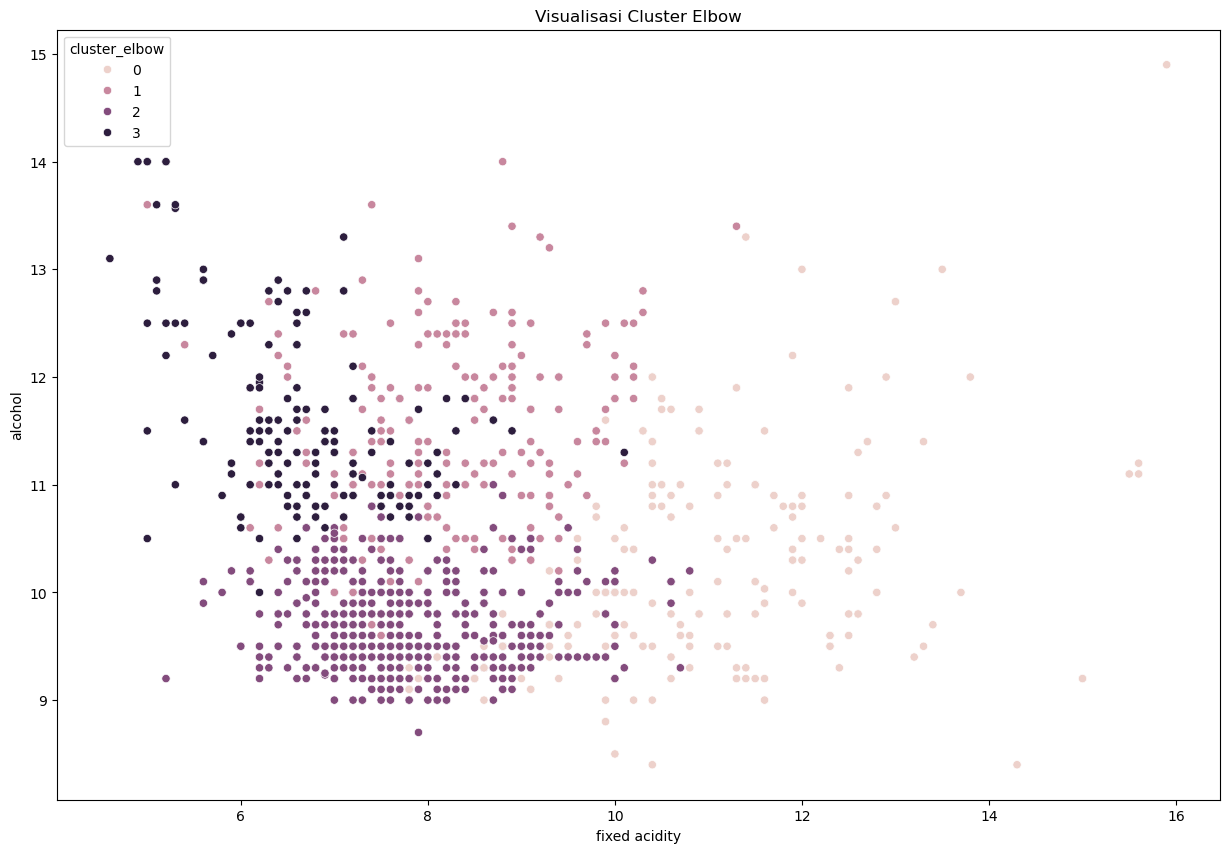

In [18]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_elbow')
plt.title('Visualisasi Cluster Elbow')
plt.show()

### Bandingkan hasil dengan label anotator

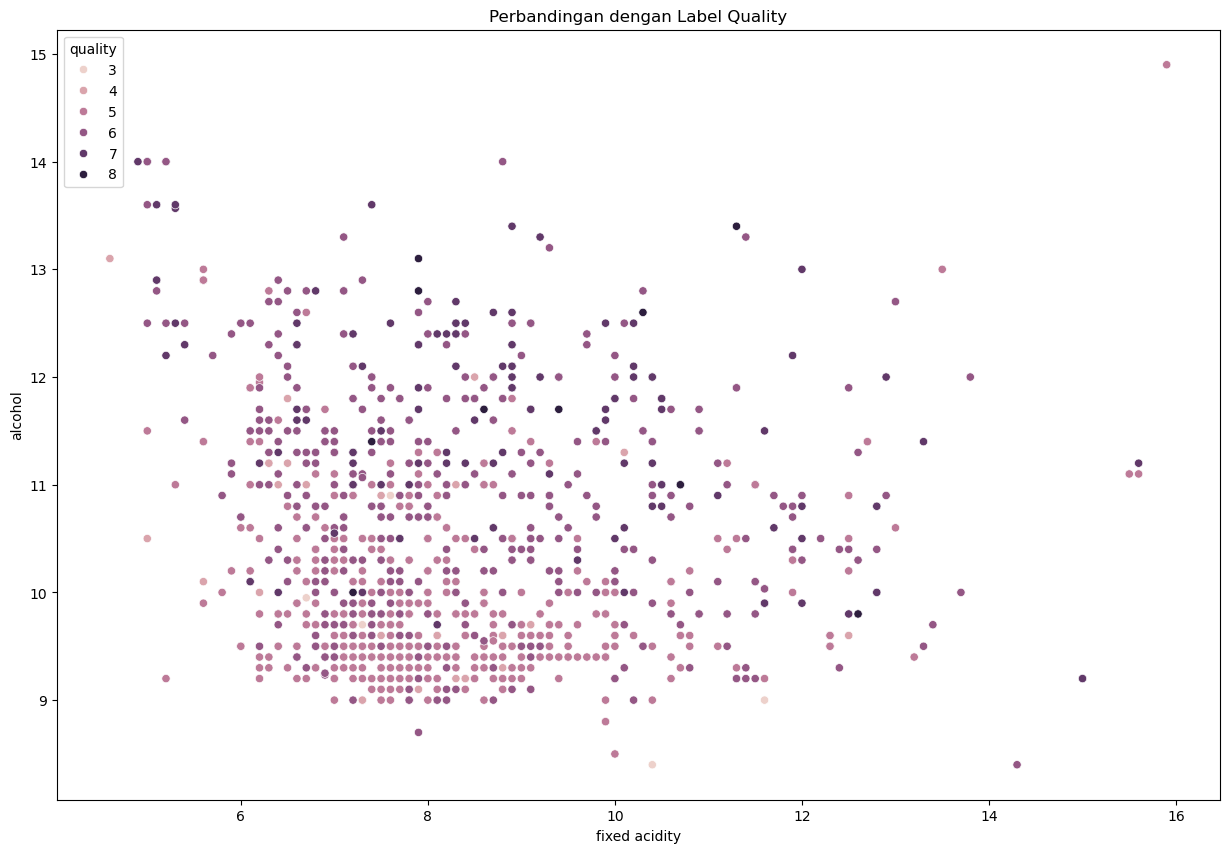

In [19]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='quality')
plt.title('Perbandingan dengan Label Quality')
plt.show()

### Hasil clustering menunjukkan data wine berhasil dikelompokkan berdasarkan kemiripan karakteristik kimia seperti acidity dan alcohol. 
Setiap cluster memiliki pola kualitas wine yang berbeda sehingga K-Means cukup efektif untuk melihat kelompok data pada dataset WineQT.

### 2. Via Score Plot

In [20]:
# yellowbrick tidak dipakai agar notebook tetap bisa dijalankan tanpa error

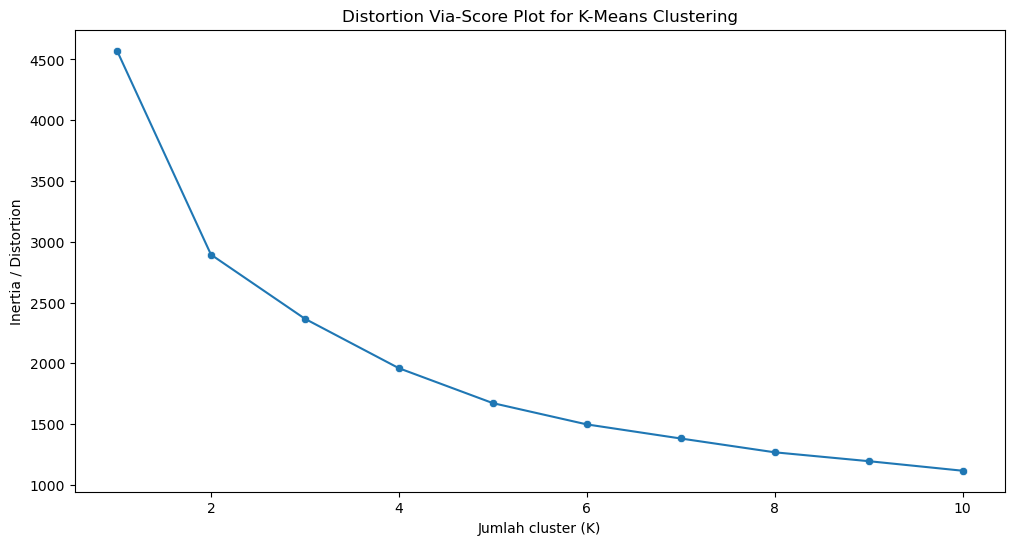

In [21]:
# Via Score Plot sederhana tanpa yellowbrick
from sklearn.cluster import KMeans

inertia_via = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(df_scalling.values)
    inertia_via.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, 11), y=inertia_via)
sns.scatterplot(x=range(1, 11), y=inertia_via)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.xlabel('Jumlah cluster (K)')
plt.ylabel('Inertia / Distortion')
plt.show()

In [22]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [23]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [24]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,2,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,2,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,2,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,3,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,2,2
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3,2
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

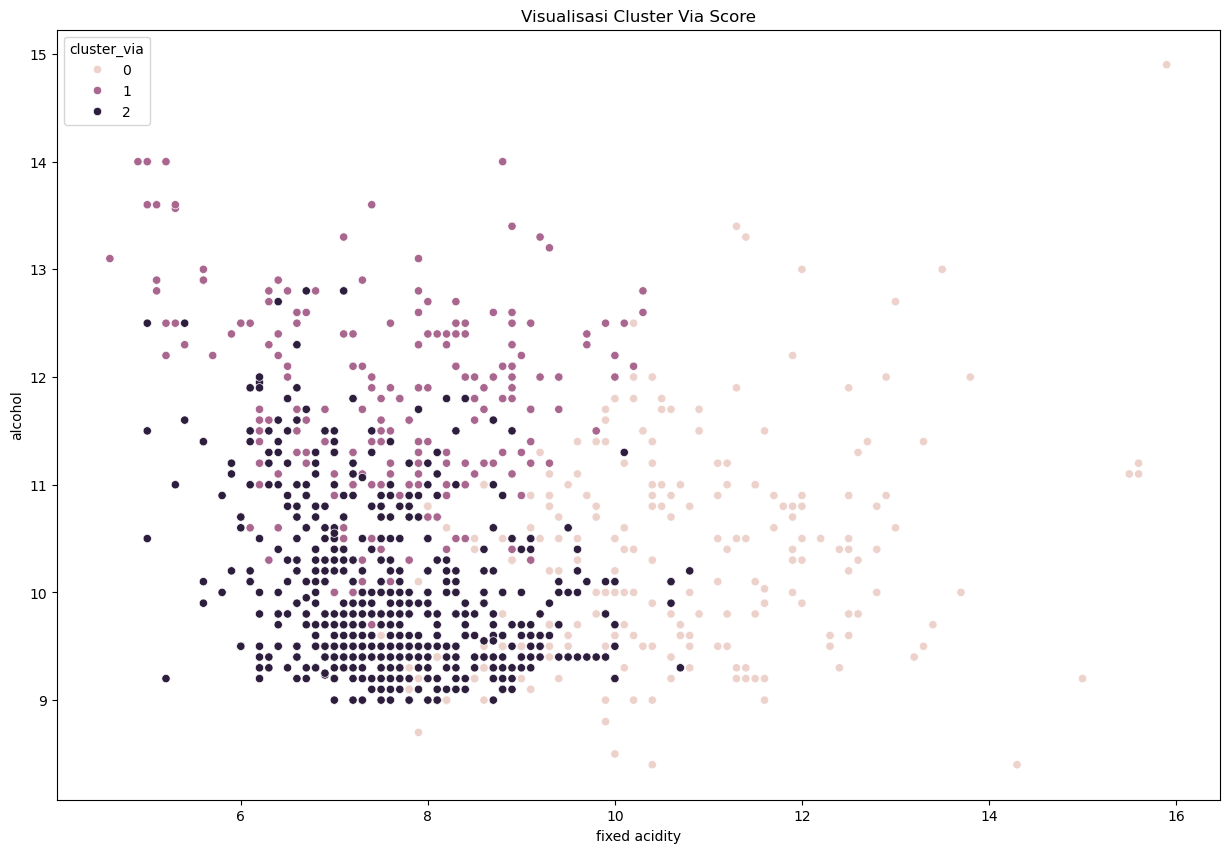

In [25]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_via', ax=ax)
plt.title('Visualisasi Cluster Via Score')
plt.show()

### Bandingkan dengan label anotator

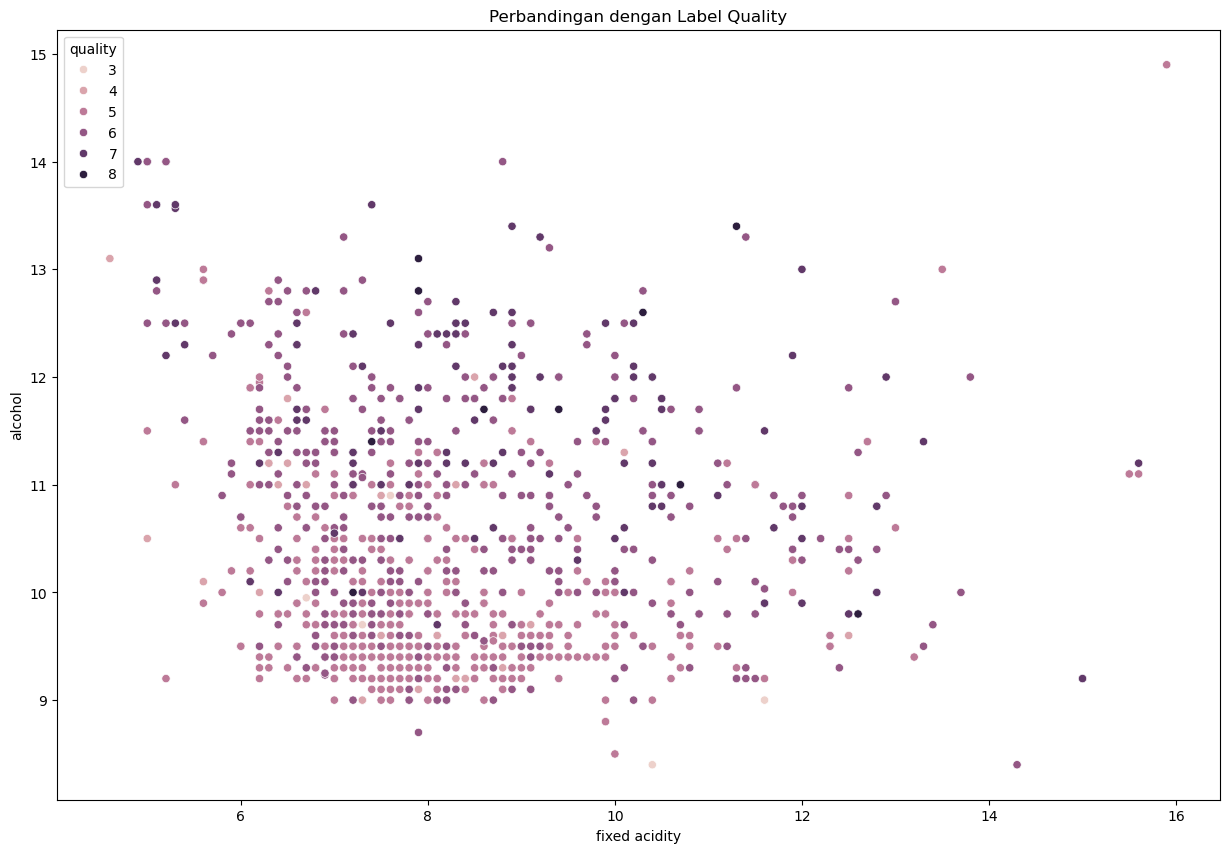

In [26]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='quality')
plt.title('Perbandingan dengan Label Quality')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini

1. Cluster 0 berisi data dengan berat lebih rendah dan tinggi sedang. Cluster ini menunjukkan kelompok individu dengan postur relatif ringan.
2. Cluster 1 berisi data dengan berat lebih tinggi tetapi tinggi relatif lebih rendah. Cluster ini menggambarkan kelompok individu dengan badan lebih besar namun tidak terlalu tinggi.
3. Cluster 2 berisi data dengan tinggi paling tinggi dan berat sedang hingga tinggi. Cluster ini menunjukkan kelompok individu dengan postur lebih tinggi dibanding cluster lainnya.

### Thank you :)